In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import joblib
import os

# Column names (same as before)
columns = ['engine_id', 'cycle'] + \
          [f'op_setting_{i}' for i in range(1, 4)] + \
          [f's{i}' for i in range(1, 22)]

train = pd.read_csv('../data/raw/train_FD001.txt',
                    sep=r'\s+', header=None, names=columns)
test = pd.read_csv('../data/raw/test_FD001.txt',
                   sep=r'\s+', header=None, names=columns)
rul_test = pd.read_csv('../data/raw/RUL_FD001.txt',
                       sep=r'\s+', header=None, names=['RUL'])

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

Train shape: (20631, 26)
Test shape: (13096, 26)


In [2]:
# Sensors to drop - flat, no information
useless_sensors = ['s1', 's5', 's6', 's10', 's16', 's18', 's19']

# Your 6 key sensors from exploration
key_sensors = ['s4', 's7', 's11', 's12', 's15', 's20']

# All useful sensors (key + remaining non-flat ones)
all_useful_sensors = [f's{i}' for i in range(1, 22) 
                      if f's{i}' not in useless_sensors]

print(f"Dropping: {useless_sensors}")
print(f"Key sensors: {key_sensors}")
print(f"All useful sensors: {all_useful_sensors}")

Dropping: ['s1', 's5', 's6', 's10', 's16', 's18', 's19']
Key sensors: ['s4', 's7', 's11', 's12', 's15', 's20']
All useful sensors: ['s2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']


In [3]:
def add_rul(df):
    max_cycles = df.groupby('engine_id')['cycle'].max().reset_index()
    max_cycles.columns = ['engine_id', 'max_cycle']
    df = df.merge(max_cycles, on='engine_id')
    df['RUL'] = df['max_cycle'] - df['cycle']
    df = df.drop(columns=['max_cycle'])
    return df

train = add_rul(train)

# Cap RUL at 125
RUL_CAP = 125
train['RUL'] = train['RUL'].clip(upper=RUL_CAP)

print(f"RUL range after capping: {train['RUL'].min()} to {train['RUL'].max()}")
print(train[['engine_id', 'cycle', 'RUL']].head(10))

RUL range after capping: 0 to 125
   engine_id  cycle  RUL
0          1      1  125
1          1      2  125
2          1      3  125
3          1      4  125
4          1      5  125
5          1      6  125
6          1      7  125
7          1      8  125
8          1      9  125
9          1     10  125


In [4]:
def add_rolling_features(df, sensors, windows=[5, 10, 30]):
    df = df.sort_values(['engine_id', 'cycle'])
    
    for sensor in sensors:
        for window in windows:
            # Rolling mean
            df[f'{sensor}_mean_{window}'] = (
                df.groupby('engine_id')[sensor]
                .transform(lambda x: x.rolling(window, min_periods=1).mean())
            )
            # Rolling std
            df[f'{sensor}_std_{window}'] = (
                df.groupby('engine_id')[sensor]
                .transform(lambda x: x.rolling(window, min_periods=1).std().fillna(0))
            )
    
    return df

train = add_rolling_features(train, all_useful_sensors)
test = add_rolling_features(test, all_useful_sensors)

print(f"Train shape after rolling features: {train.shape}")
print("New columns sample:", [c for c in train.columns if 'mean' in c][:5])

/var/folders/08/kv_ghcdx2pg5_m7j622rvww00000gn/T/ipykernel_22356/1366052874.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{sensor}_std_{window}'] = (
/var/folders/08/kv_ghcdx2pg5_m7j622rvww00000gn/T/ipykernel_22356/1366052874.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{sensor}_mean_{window}'] = (
/var/folders/08/kv_ghcdx2pg5_m7j622rvww00000gn/T/ipykernel_22356/1366052874.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has

Train shape after rolling features: (20631, 111)
New columns sample: ['s2_mean_5', 's2_mean_10', 's2_mean_30', 's3_mean_5', 's3_mean_10']


/var/folders/08/kv_ghcdx2pg5_m7j622rvww00000gn/T/ipykernel_22356/1366052874.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{sensor}_mean_{window}'] = (
/var/folders/08/kv_ghcdx2pg5_m7j622rvww00000gn/T/ipykernel_22356/1366052874.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'{sensor}_std_{window}'] = (
/var/folders/08/kv_ghcdx2pg5_m7j622rvww00000gn/T/ipykernel_22356/1366052874.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has 

In [5]:
cols_to_drop = useless_sensors + ['op_setting_1', 'op_setting_2', 'op_setting_3']

train = train.drop(columns=cols_to_drop)
test = test.drop(columns=cols_to_drop)

print(f"Train shape after dropping: {train.shape}")
print(f"Test shape after dropping: {test.shape}")

Train shape after dropping: (20631, 101)
Test shape after dropping: (13096, 100)


In [6]:
# Columns to scale - everything except engine_id, cycle, RUL
feature_cols = [c for c in train.columns 
                if c not in ['engine_id', 'cycle', 'RUL']]

scaler = MinMaxScaler()

train[feature_cols] = scaler.fit_transform(train[feature_cols])
test[feature_cols] = scaler.transform(test[feature_cols])

print(f"Number of features: {len(feature_cols)}")
print("Feature range check:")
print(train[feature_cols].describe().loc[['min', 'max']].T.head(10))

Number of features: 98
Feature range check:
     min  max
s2   0.0  1.0
s3   0.0  1.0
s4   0.0  1.0
s7   0.0  1.0
s8   0.0  1.0
s9   0.0  1.0
s11  0.0  1.0
s12  0.0  1.0
s13  0.0  1.0
s14  0.0  1.0


In [7]:
# Each engine in test gets one RUL value - at its last recorded cycle
rul_test['engine_id'] = rul_test.index + 1

# Merge onto the last cycle of each test engine
test_last_cycle = test.groupby('engine_id')['cycle'].max().reset_index()
test_last_cycle = test_last_cycle.merge(rul_test, on='engine_id')
test_last_cycle.columns = ['engine_id', 'cycle', 'true_RUL']

print(test_last_cycle.head(10))
print(f"\nTrue RUL range: {test_last_cycle['true_RUL'].min()} to {test_last_cycle['true_RUL'].max()}")

   engine_id  cycle  true_RUL
0          1     31       112
1          2     49        98
2          3    126        69
3          4    106        82
4          5     98        91
5          6    105        93
6          7    160        91
7          8    166        95
8          9     55       111
9         10    192        96

True RUL range: 7 to 145


In [8]:
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

train.to_csv('../data/processed/train_features.csv', index=False)
test.to_csv('../data/processed/test_features.csv', index=False)
test_last_cycle.to_csv('../data/processed/test_rul_labels.csv', index=False)

# Save feature column list and scaler for use in the app later
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(feature_cols, '../models/feature_cols.pkl')

print("Saved:")
print(f"  train_features.csv — {train.shape}")
print(f"  test_features.csv  — {test.shape}")
print(f"  test_rul_labels.csv — {test_last_cycle.shape}")
print(f"  scaler.pkl")
print(f"  feature_cols.pkl")

Saved:
  train_features.csv — (20631, 101)
  test_features.csv  — (13096, 100)
  test_rul_labels.csv — (100, 3)
  scaler.pkl
  feature_cols.pkl


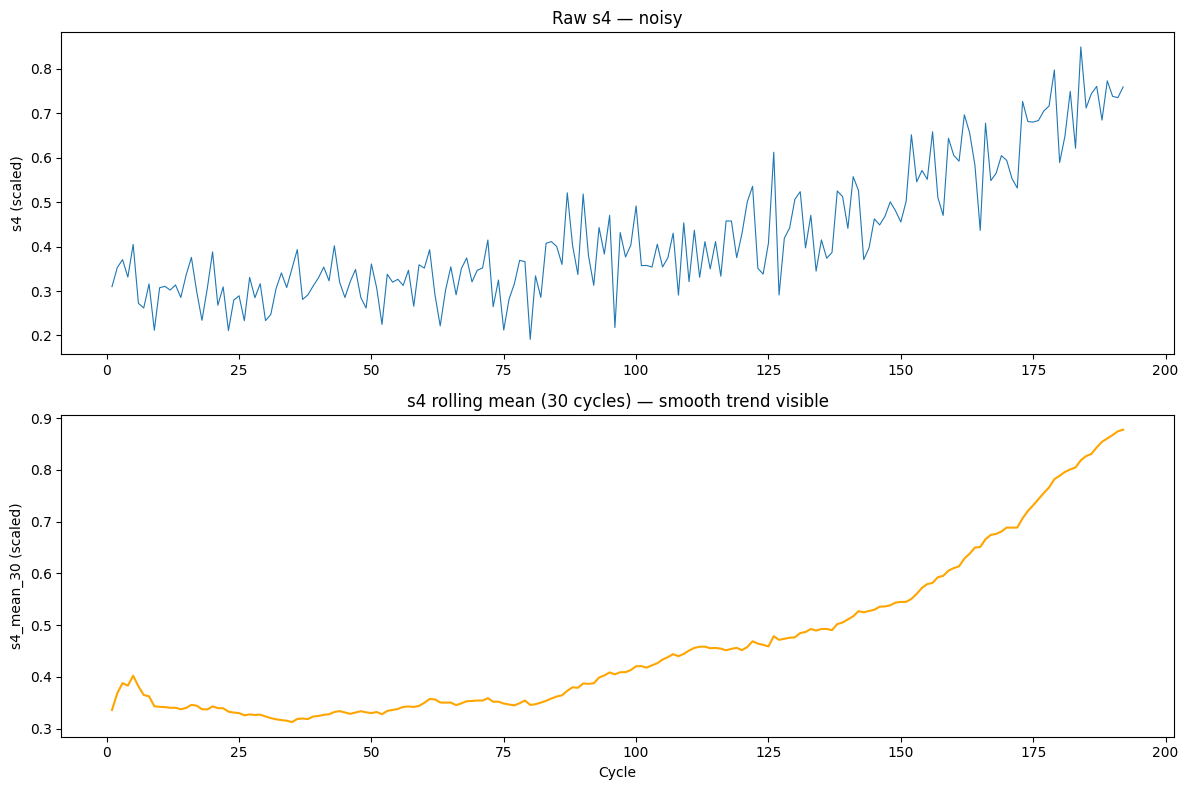

In [9]:
engine_data = train[train['engine_id'] == 1].sort_values('cycle')

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Raw sensor
axes[0].plot(engine_data['cycle'], engine_data['s4'], 
             linewidth=0.8, label='raw s4')
axes[0].set_title('Raw s4 — noisy')
axes[0].set_ylabel('s4 (scaled)')

# Rolling mean of same sensor
axes[1].plot(engine_data['cycle'], engine_data['s4_mean_30'],
             linewidth=1.5, label='s4 rolling mean (30 cycles)', color='orange')
axes[1].set_title('s4 rolling mean (30 cycles) — smooth trend visible')
axes[1].set_ylabel('s4_mean_30 (scaled)')
axes[1].set_xlabel('Cycle')

plt.tight_layout()
plt.show()